# Predicting Objective Changes with Gradient Boosted Trees

This notebook predicts each submission's **`slider_value_changes_frac`** — a 5-element vector over the
objectives **REB, AST, STL, BLK, PTS** — from the **`mrs`** matrix (5×5 marginal rates of substitution,
diagonal reset to 1) and the **`initial_slider_values`** recorded on that submission, pooling data
across all 10 subjects.

The model throughout is a **gradient boosted decision tree** (`GradientBoostingRegressor`), fit as five
independent single-output regressions — one per objective. The evaluation throughout is a **staggered
per-subject trial holdout**,

In [1]:
import re
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("viridis", 5)
plt.rcParams["figure.dpi"] = 110

OBJ_NAMES = ["REB", "AST", "STL", "BLK", "PTS"]


## 1. Load & parse the pooled dataset

`slider_value_changes_frac`, `mrs`, and `initial_slider_values` are stored as printed numpy arrays (not valid JSON), so we parse them with small regex-based helpers. Rows where `mrs` is empty (`[]`) are dropped: `mrs` is only computed from the second submission of a trial onward, so a trial's first submission has nothing to predict from. Every vector and matrix is ordered **REB, AST, STL, BLK, PTS**.

In [2]:
def parse_vec(s):
    s = s.strip()
    if s == '[]':
        return None
    parts = [p for p in re.split(r'\s+', s[1:-1].strip()) if p != '']
    return np.array([float(p) for p in parts])

def parse_mat(s):
    s = s.strip()
    if s == '[]':
        return None
    mat = []
    for r in s[1:-1].strip().split('\n'):
        r = r.strip()
        if r.startswith('['):
            r = r[1:]
        if r.endswith(']'):
            r = r[:-1]
        parts = [p for p in re.split(r'\s+', r.strip()) if p != '']
        mat.append([float(p) for p in parts])
    return np.array(mat)

def parse_simple_vec(s):
    return np.array([float(x) for x in s.strip('[]').split(',')])

df = pd.read_csv('all_info_10.csv')
df['change_vec'] = df['slider_value_changes_frac'].apply(parse_vec)
df['mrs_mat'] = df['mrs'].apply(parse_mat)
df['init_vec'] = df['initial_slider_values'].apply(parse_simple_vec)

sub = df[df['mrs_mat'].notna()].copy()
sub = sub[sub['mrs_mat'].apply(lambda m: m.shape == (5, 5))].reset_index(drop=True)

# The mrs diagonal is stored as 0; an objective trades against itself 1:1, so set it to 1.
for i in sub.index:
    m = sub.at[i, 'mrs_mat'].copy()
    np.fill_diagonal(m, 1.0)
    sub.at[i, 'mrs_mat'] = m

print(f"{len(sub)} usable rows out of {len(df)} total submissions")


453 usable rows out of 623 total submissions


## 2. Data overview

In [3]:
overview = pd.DataFrame({
    "value": [
        df['sub_id'].nunique(),
        len(df),
        len(sub),
        sub[['sub_id', 'trial_id']].drop_duplicates().shape[0],
        sub['trial_id'].nunique(),
    ]
}, index=["Subjects", "Total submissions", "Usable rows (mrs present)",
          "Distinct subject-trial groups", "Distinct trial numbers"])
overview


,value
Subjects,10
Total submissions,623
Usable rows (mrs present),453
Distinct subject-trial groups,158
Distinct trial numbers,17


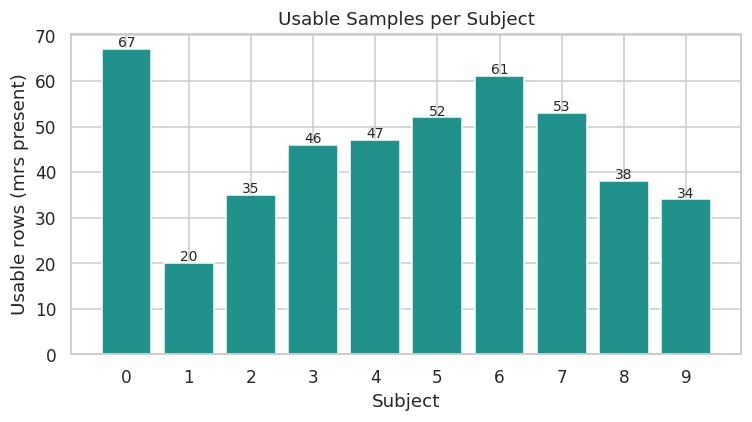

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
counts = sub.groupby('sub_id').size()
ax.bar(counts.index.astype(str), counts.values, color=PALETTE[2])
ax.set_xlabel("Subject")
ax.set_ylabel("Usable rows (mrs present)")
ax.set_title("Usable Samples per Subject")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 3. Feature engineering: ways to summarize the mrs matrix

The predictor for each submission is a 5×5 matrix `M`, where `M[i, j]` is the marginal rate of
substitution between objectives *i* and *j*, with the diagonal set to 1. The target is a 5-element
vector. So we need to turn a matrix into features.

The matrix is **not symmetric**, which gives two distinct one-number summaries per objective:

- **Row mean** for objective *i*: the average of `M[i, :]` excluding the diagonal — "how much does *i*
  trade off against the other four, on average", reading **across**.
- **Column mean** for objective *i*: the average of `M[:, i]` excluding the diagonal — "how much do the
  other four trade off against *i*", reading **down**.

For a worked example, take the first submission's matrix. `row_mean_REB` averages the four
off-diagonal entries in REB's row; `col_mean_REB` averages the four in REB's column. These are
genuinely different numbers.

We build four candidate representations of `mrs`, plus the raw starting values:

| Name | Shape | What it is |
|---|---|---|
| `X_row` | 5 | row means only |
| `X_col` | 5 | column means only |
| `X_rc` | 10 | row means + column means |
| `X_full` | 20 | every off-diagonal entry, unaggregated |
| `X_init` | 5 | `initial_slider_values` (no `mrs` at all) |

Section 6 compares these head-to-head. The question is whether aggregating the matrix throws away
signal the trees could have used, or whether it removes noise they would otherwise have chased.


In [5]:
example = sub.iloc[0]
M = example['mrs_mat']
print(f"Example submission — subject {example['sub_id']}, trial {example['trial_id']}")
print(pd.DataFrame(M, index=OBJ_NAMES, columns=OBJ_NAMES).round(2).to_string())

off = M.copy()
np.fill_diagonal(off, np.nan)
print(f"\nrow_mean_REB = mean of REB's row, ex-diagonal = {np.nanmean(off[0, :]):.3f}")
print(f"col_mean_REB = mean of REB's column, ex-diagonal = {np.nanmean(off[:, 0]):.3f}")


Example submission — subject 0, trial 1
      REB   AST   STL   BLK   PTS
REB  1.00 -0.37 -0.64 -0.36 -0.42
AST -0.62  1.00 -0.77 -0.89 -0.30
STL -0.16 -0.11  1.00 -0.16  0.01
BLK -0.38 -0.35 -0.77  1.00 -0.07
PTS -0.29 -0.19 -0.53 -0.54  1.00

row_mean_REB = mean of REB's row, ex-diagonal = -0.448
col_mean_REB = mean of REB's column, ex-diagonal = -0.363


In [6]:
Y = np.vstack(sub['change_vec'].values)

def row_col_feats(m):
    off = m.copy()
    np.fill_diagonal(off, np.nan)
    return np.concatenate([np.nanmean(off, axis=1), np.nanmean(off, axis=0)])

X_rc = np.vstack([row_col_feats(m) for m in sub['mrs_mat']])
X_row, X_col = X_rc[:, :5], X_rc[:, 5:]

offdiag_idx = [(i, j) for i in range(5) for j in range(5) if i != j]
X_full = np.vstack([np.array([m[i, j] for (i, j) in offdiag_idx]) for m in sub['mrs_mat']])

X_init = np.vstack(sub['init_vec'].values)

names_row = [f"row_mean_{n}" for n in OBJ_NAMES]
names_col = [f"col_mean_{n}" for n in OBJ_NAMES]
names_init = [f"initial_{n}" for n in OBJ_NAMES]

print("X_row:", X_row.shape, " X_col:", X_col.shape, " X_rc:", X_rc.shape,
      " X_full:", X_full.shape, " X_init:", X_init.shape, " Y:", Y.shape)


X_row: (453, 5)  X_col: (453, 5)  X_rc: (453, 10)  X_full: (453, 20)  X_init: (453, 5)  Y: (453, 5)


## 4. Cross-validation: the staggered per-subject trial holdout

This is the only evaluation scheme used in this notebook, so it's worth stating precisely.

**The setup.** Every subject completed 17 trials, in order, and each trial can contain several
submissions. Rows from the same subject are not independent and
neither are rows from the same trial.

**Staggering** Each fold holds out exactly one trial per subject, but *which* trial
number is staggered across subjects, so that no two subjects contribute the same trial number to the
same fold. With subjects indexed $s = 0, \dots, 9$ and observed trial numbers enumerated
$t_0 < t_1 < \dots < t_{n_T-1}$, in fold $f$ subject $s$ holds out trial number
$t_{(f + s) \bmod n_T}$ — a cyclic, Latin-square-style shift:

| | Fold 0 holds out | Fold 1 holds out | Fold 2 holds out |
|---|---|---|---|
| Subject 0 | trial 1 | trial 2 | trial 3 |
| Subject 1 | trial 2 | trial 3 | trial 4 |
| Subject 2 | trial 3 | trial 4 | trial 5 |
| ... | ... | ... | ... |

Because the 10 per-subject offsets are distinct mod $n_T$, **every fold holds out 10 different trial
numbers, one per subject**, and across all $n_T$ folds each subject has each of their own trials held
out exactly once. 
Since only one trial is removed per subject, the
training set for any fold still contains roughly 16 of that subject's 17 trials. So this measures:
*given almost everything about this person, how well can we predict their one remaining trial?* That
isolates whether `mrs` carries trial-level information within a person.  Thus the results should be interepreted as within subject


In [7]:
trial_numbers = sorted(sub['trial_id'].unique())
subjects = sorted(sub['sub_id'].unique())
n_trial_numbers, n_subjects = len(trial_numbers), len(subjects)

fold_id = np.full(len(sub), -1)
for f in range(n_trial_numbers):
    for s_idx, s in enumerate(subjects):
        target_trial = trial_numbers[(f + s_idx) % n_trial_numbers]
        mask = (sub['sub_id'] == s) & (sub['trial_id'] == target_trial)
        fold_id[mask.values] = f

assert (fold_id == -1).sum() == 0, "every row should be assigned to exactly one fold"
print(f"{n_trial_numbers} folds across {n_subjects} subjects; {len(sub)} rows all assigned")

check = sub.assign(fold=fold_id)
for f in [0, 1]:
    held = check[check['fold'] == f][['sub_id', 'trial_id']].drop_duplicates().sort_values('sub_id')
    pairs = ", ".join(f"S{int(r.sub_id)}:t{int(r.trial_id)}" for r in held.itertuples())
    print(f"\nFold {f} holds out — {pairs}")
    assert held['trial_id'].nunique() == len(held), "trial numbers must be distinct within a fold"


17 folds across 10 subjects; 453 rows all assigned

Fold 0 holds out — S0:t1, S1:t2, S2:t3, S3:t4, S4:t5, S5:t6, S6:t7, S7:t8, S8:t9, S9:t10

Fold 1 holds out — S0:t2, S1:t3, S2:t4, S3:t5, S4:t6, S5:t7, S6:t8, S7:t9, S8:t10, S9:t11


In [8]:
def eval_gbdt(X, cfg, Yc=None):
    """Staggered per-subject trial holdout CV.

    Fits 5 independent GradientBoostingRegressor models (one per objective) on each
    training fold and predicts the held-out rows. Returns per-objective R^2 and the
    pooled R^2 over all objectives and rows.
    """
    Yc = Y if Yc is None else Yc
    preds = np.zeros_like(Yc)
    for f in range(n_trial_numbers):
        test = fold_id == f
        train = ~test
        for k in range(5):
            m = GradientBoostingRegressor(random_state=0, **cfg)
            m.fit(X[train], Yc[train, k])
            preds[test, k] = m.predict(X[test])
    r2s = np.array([r2_score(Yc[:, k], preds[:, k]) for k in range(5)])
    overall = r2_score(Yc.ravel(), preds.ravel())
    return r2s, overall, preds


## 5. Hyperparameter selection

We grid-search a small space of deliberately conservative settings — shallow trees, few estimators, a
low learning rate, and subsampling — because with 453 rows and 17 folds a flexible booster will
happily fit noise. The search runs under the same staggered CV used everywhere else.


In [9]:
X_default = np.hstack([X_rc, X_init])  # provisional feature set for tuning; revisited in Section 6

grid_rows = []
for n_est, depth, lr in itertools.product([50, 100], [1, 2], [0.05, 0.08]):
    cfg = dict(n_estimators=n_est, max_depth=depth, learning_rate=lr, subsample=0.8)
    _, overall, _ = eval_gbdt(X_default, cfg)
    grid_rows.append({"n_estimators": n_est, "max_depth": depth,
                      "learning_rate": lr, "overall R2": overall})

grid_df = pd.DataFrame(grid_rows).sort_values("overall R2", ascending=False).reset_index(drop=True)
grid_df.round(4)


,n_estimators,max_depth,learning_rate,overall R2
0,50,2,0.05,0.1550
1,100,1,0.05,0.1543
2,50,1,0.08,0.1501
3,100,1,0.08,0.1440
4,100,2,0.05,0.1440
5,50,2,0.08,0.1417
6,50,1,0.05,0.1412
7,100,2,0.08,0.1107


In [10]:
GBDT_CFG = dict(n_estimators=50, max_depth=2, learning_rate=0.05, subsample=0.8)
print("Selected configuration:", GBDT_CFG)


Selected configuration: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.8}


The best setting is a modest one — 50 shallow (depth-2) trees at a 0.05 learning rate — and the spread across the whole grid is small compared with the spread across *feature representations* in the next section. That ordering is the useful takeaway: on this dataset, how the `mrs` matrix is summarized matters considerably more than how the booster is tuned.

## 6. Which feature representation works best?

Now the central question. We hold the model fixed and vary only the features, comparing the `mrs`
summaries from Section 3 alone and in combination with `initial_slider_values`.


In [11]:
X_row_init = np.hstack([X_row, X_init])
X_rc_init = np.hstack([X_rc, X_init])
X_full_init = np.hstack([X_full, X_init])
X_everything = np.hstack([X_full, X_rc, X_init])

feature_sets = [
    ("column means only",            X_col),
    ("initial values only",          X_init),
    ("row means only",               X_row),
    ("row + column means",           X_rc),
    ("full off-diagonal (20)",       X_full),
    ("row means + initial",          X_row_init),
    ("row + column means + initial", X_rc_init),
    ("full off-diagonal + initial",  X_full_init),
    ("everything",                   X_everything),
]

fs_rows = []
fs_r2s = {}
for label, X_ in feature_sets:
    r2s, overall, _ = eval_gbdt(X_, GBDT_CFG)
    fs_rows.append({"feature set": label, "n features": X_.shape[1], "overall R2": overall})
    fs_r2s[label] = r2s

fs_df = pd.DataFrame(fs_rows).set_index("feature set")
fs_df.round(4)


,n features,overall R2
feature set,,
column means only,5,0.0496
initial values only,5,0.1017
row means only,5,0.1359
row + column means,10,0.1376
full off-diagonal (20),20,0.0983
row means + initial,10,0.1551
row + column means + initial,15,0.1550
full off-diagonal + initial,25,0.1251
everything,35,0.1391


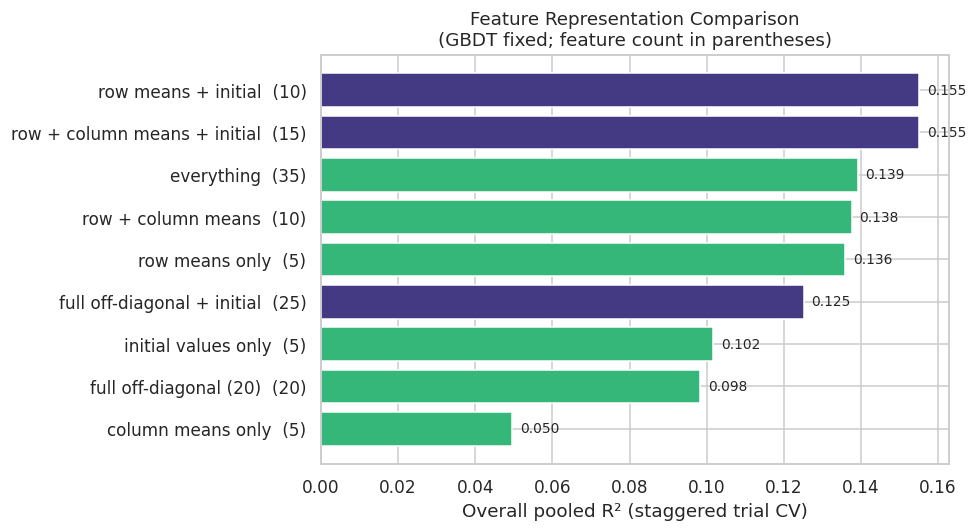

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
order = fs_df.sort_values("overall R2")
colors = [PALETTE[0] if "initial" in str(idx) and "only" not in str(idx) else PALETTE[3]
          for idx in order.index]
ax.barh(range(len(order)), order["overall R2"], color=colors)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{idx}  ({int(n)})" for idx, n in zip(order.index, order["n features"])])
ax.set_xlabel("Overall pooled R² (staggered trial CV)")
ax.set_title("Feature Representation Comparison\n(GBDT fixed; feature count in parentheses)")
for i, v in enumerate(order["overall R2"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.show()


Four things stand out, and they are largely about **what to throw away**:

1. **Row means carry essentially all of the `mrs` signal.** Row means alone (5 features) reach 0.136; adding column means to make the 10-feature set moves it only to 0.138. Column means *alone* manage just 0.050 — far worse than row means alone, and worse than the starting values.
2. **Aggregating beats not aggregating, decisively.** The full 20-entry off-diagonal matrix scores 0.098, well below the 5-feature row means (0.136) built from those very same numbers. With 453 rows, the individual entries give a greedy tree-builder many more chances to split on noise; averaging across each row acts as a form of regularization the trees benefit from.
3. **`initial_slider_values` add real, complementary information.** Row means + initial values reaches **0.155**, clearly above either component alone (0.136 and 0.102).
4. **More features are not better past that point.** The 15-feature set ties the 10-feature one (0.155 both), and throwing everything together (35 features) *drops* to 0.139.

The parsimonious conclusion: **row means + initial values (10 features)** is the model to prefer. It matches the best score with fewer inputs, and the redundancy of column means is a genuine finding rather than an artifact — how much an objective trades away against the others predicts its change; how much the others trade away against it adds almost nothing on top.

In [13]:
per_obj = pd.DataFrame({label: fs_r2s[label] for label, _ in feature_sets}, index=OBJ_NAMES).T
per_obj.round(3)


,REB,AST,STL,BLK,PTS
column means only,-0.038,0.037,0.072,0.019,0.201
initial values only,-0.036,0.059,0.117,0.157,0.193
row means only,0.150,0.078,0.188,0.100,0.205
row + column means,0.131,0.083,0.188,0.098,0.240
full off-diagonal (20),0.083,0.081,0.066,0.119,0.145
row means + initial,0.148,0.105,0.204,0.135,0.203
row + column means + initial,0.144,0.106,0.193,0.144,0.208
full off-diagonal + initial,0.091,0.086,0.119,0.138,0.215
everything,0.120,0.075,0.160,0.157,0.199


Per objective, the pattern mostly holds, with one nuance: **PTS is the objective that leans most on the starting values** (0.193 from initial values alone, its best single-source score), while **REB leans almost entirely on `mrs`** (0.150 from row means alone, versus −0.036 from initial values — worse than predicting the mean). This is why the combination beats either part.

## 7. Final model: performance by objective

We adopt **row means + `initial_slider_values`** (10 features) with the Section 5 configuration.


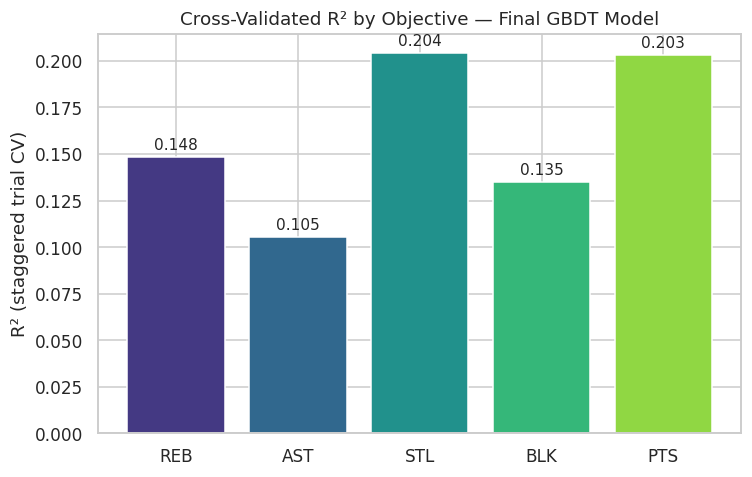

Overall pooled R²: 0.155


In [21]:
FINAL_FEATURES = X_row_init
final_names = names_row + names_init

r2s_final, overall_final, preds_final = eval_gbdt(FINAL_FEATURES, GBDT_CFG)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(OBJ_NAMES, r2s_final, color=PALETTE)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_ylabel("R² (staggered trial CV)")
ax.set_title("Cross-Validated R² by Objective — Final GBDT Model")
for bar, v in zip(bars, r2s_final):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.004, f"{v:.3f}", ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f"Overall pooled R²: {overall_final:.3f}")


Performance is reasonably even: STL (0.204) and PTS (0.203) predict best, AST (0.105) worst, with REB and BLK in between. **Overall pooled R² is 0.155**  — a modest effect in absolute terms, leaving most of the variance in how subjects adjust these sliders unexplained, 
but a consistent one across all five objectives. Section 9 checks it against chance.

## 8. What the model uses: feature importances

Refitting on all rows (no CV split) to inspect which inputs the trees actually split on.

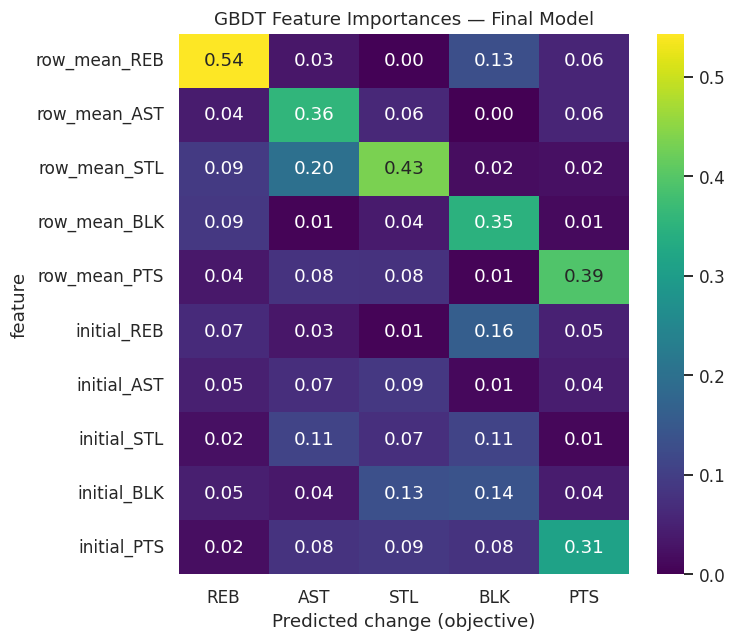

In [15]:
imp_table = pd.DataFrame(index=final_names)
for k, name in enumerate(OBJ_NAMES):
    m = GradientBoostingRegressor(random_state=0, **GBDT_CFG).fit(FINAL_FEATURES, Y[:, k])
    imp_table[name] = m.feature_importances_

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(imp_table, annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("GBDT Feature Importances — Final Model")
ax.set_xlabel("Predicted change (objective)")
ax.set_ylabel("feature")
plt.tight_layout()
plt.show()


In [16]:
own_rows = []
for k, name in enumerate(OBJ_NAMES):
    col = imp_table[name].sort_values(ascending=False)
    own_rows.append({"objective": name,
                     "own row_mean importance": imp_table.loc[f"row_mean_{name}", name],
                     "own initial importance": imp_table.loc[f"initial_{name}", name],
                     "top feature overall": col.index[0]})
pd.DataFrame(own_rows).set_index("objective").round(3)


,own row_mean importance,own initial importance,top feature overall
objective,,,
REB,0.543,0.066,row_mean_REB
AST,0.356,0.072,row_mean_AST
STL,0.433,0.074,row_mean_STL
BLK,0.347,0.138,row_mean_BLK
PTS,0.394,0.313,row_mean_PTS


The structure is clean and consistent: **each objective's own row-mean `mrs` is its most important feature**, by a wide margin in most cases. Its own starting value is typically the next most useful input, most visibly for PTS. Cross-objective terms matter comparatively little — the model is largely learning five parallel same-objective relationships rather than a densely coupled system.

Substantively, and recalling that `mrs` values here are almost always negative: **the less an objective costs to acquire relative to the others, the more of it subjects take.**

## 9. Is this level of cross-validated R² meaningful?

An overall R² of 0.155 is modest, so it is worth asking whether it is distinguishable from chance. We
run a **permutation test**: shuffle which `slider_value_changes_frac` vector is paired with which row's
features — destroying any true relationship while preserving each variable's own distribution — and
rerun the *identical* staggered CV pipeline, with the same features and the same fixed hyperparameters,
on the shuffled data. Repeating this many times builds the null distribution of R² we would expect if
the features carried no information at all.

GBDT is slow to permute (each refit grows a fresh ensemble rather than solving a closed-form system),
so 100 permutations take roughly 9 minutes. By default this loads a **cached result**; set
`RUN_PERMUTATION_TEST = True` to regenerate it. The full generating code is below either way. Note
that 100 permutations puts a floor of 1/101 ≈ 0.0099 on the achievable p-value. **I suggest report as p < 0.01**.

The cached run uses the **same 10-feature final model** adopted in Section 7 — identical features and
identical hyperparameters — so the test applies directly to the model reported above.


In [17]:
RUN_PERMUTATION_TEST = False   # True regenerates from scratch (~9 min); False loads the cache
PERM_N = 100
PERM_FEATURES = FINAL_FEATURES   # the same 10-feature model adopted in Section 7

if RUN_PERMUTATION_TEST:
    obs_r2s_p, obs_overall_p, _ = eval_gbdt(PERM_FEATURES, GBDT_CFG)
    rng = np.random.default_rng(9000)
    null_r2s_p = np.zeros((PERM_N, 5))
    null_overall_p = np.zeros(PERM_N)
    for i in range(PERM_N):
        perm_idx = rng.permutation(len(Y))
        r2s_i, overall_i, _ = eval_gbdt(PERM_FEATURES, GBDT_CFG, Yc=Y[perm_idx])
        null_r2s_p[i] = r2s_i
        null_overall_p[i] = overall_i
    np.savez("gbdt_perm_test_stagger.npz", obs_r2s=obs_r2s_p,
             obs_overall=np.array([obs_overall_p]), null_r2s=null_r2s_p,
             null_overall=null_overall_p, n_done=PERM_N)
    print("Regenerated the permutation cache.")
else:
    print("Loading cached permutation results (set RUN_PERMUTATION_TEST = True to regenerate).")

_p = np.load("gbdt_perm_test_stagger.npz")
obs_r2s_p = _p["obs_r2s"]
obs_overall_p = float(np.atleast_1d(_p["obs_overall"])[0])
null_r2s_p, null_overall_p, n_p = _p["null_r2s"], _p["null_overall"], int(_p["n_done"])

p_overall = (np.sum(null_overall_p >= obs_overall_p) + 1) / (n_p + 1)
print(f"n_perm={n_p}   observed overall R2={obs_overall_p:.4f}")
print(f"null: mean={null_overall_p.mean():.4f}  max={null_overall_p.max():.4f}")
print(f"permutation p-value (overall) = {p_overall:.4f}")


Loading cached permutation results (set RUN_PERMUTATION_TEST = True to regenerate).
n_perm=100   observed overall R2=0.1551
null: mean=-0.0456  max=-0.0063
permutation p-value (overall) = 0.0099


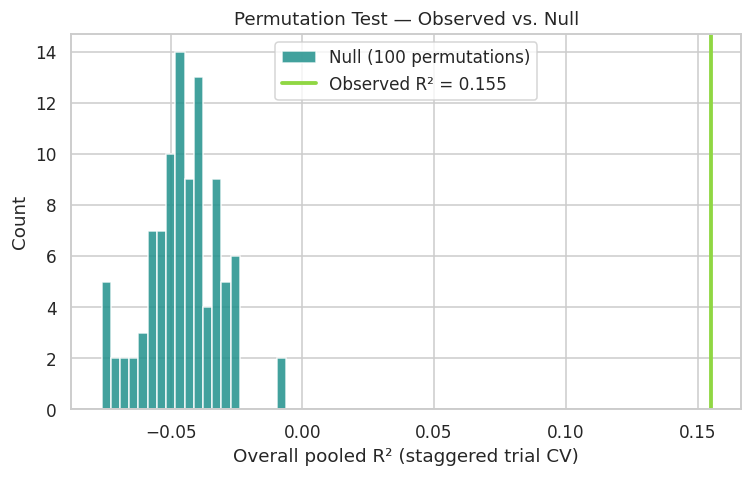

,observed R2,null mean,null max,p-value
REB,0.1482,-0.0504,0.0118,0.0099
AST,0.1052,-0.0410,0.0439,0.0099
STL,0.2043,-0.0502,0.0115,0.0099
BLK,0.1348,-0.0512,0.0190,0.0099
PTS,0.2029,-0.0555,-0.0048,0.0099


In [18]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(null_overall_p, bins=20, color=PALETTE[2], alpha=0.85, label=f"Null ({n_p} permutations)")
ax.axvline(obs_overall_p, color=PALETTE[4], linewidth=2.5, label=f"Observed R\u00b2 = {obs_overall_p:.3f}")
ax.set_xlabel("Overall pooled R\u00b2 (staggered trial CV)")
ax.set_ylabel("Count")
ax.set_title("Permutation Test — Observed vs. Null")
ax.legend()
plt.tight_layout()
plt.show()

perm_table = pd.DataFrame({"observed R2": obs_r2s_p}, index=OBJ_NAMES)
perm_table["null mean"] = null_r2s_p.mean(axis=0)
perm_table["null max"] = null_r2s_p.max(axis=0)
perm_table["p-value"] = [(np.sum(null_r2s_p[:, k] >= obs_r2s_p[k]) + 1) / (n_p + 1) for k in range(5)]
perm_table.round(4)


The null distribution sits slightly **below** zero (mean ≈ −0.046), which is expected: a model fit to shuffled targets predicts held-out rows worse than their mean does. Every objective's observed R² — including AST, the weakest at 0.105 — exceeds all 100 permutations, giving p ≈ 0.0099 throughout. **The result is a real, non-chance signal.**

## 10. Summary

- **Row means are the useful summary of the `mrs` matrix.** Row means alone (5 features) reach 0.136;
  adding column means gains almost nothing (0.138), and column means alone manage only 0.050. How much
  an objective trades away against the others predicts its change — how much the others trade away
  against it does not add to that.
- **Aggregation helps rather than hurts.** The unaggregated 20-entry off-diagonal matrix scores 0.098,
  well below the 5 row means computed from those same numbers. At 453 rows, the individual entries give
  the trees too many opportunities to split on noise.
- **`initial_slider_values` are complementary, not redundant.** Row means + initial values reaches
  **0.155**, above either alone (0.136 and 0.102). The split is objective-specific: PTS leans on
  starting values, REB almost entirely on `mrs`.
-  **The model is largely five parallel same-objective relationships.** Each objective's own row-mean
  `mrs` is its top feature, with its own starting value usually next; cross-objective terms contribute
  comparatively little. Directionally: the less an objective costs to acquire relative to the others,
  the more of it subjects take.
- **The signal is real but modest.** A permutation test puts every objective beyond all 100
  permutations (p ≈ 0.0099), yet overall R² ≈ 0.155 leaves most variance unexplained.